<a href="https://colab.research.google.com/github/Balaummaleti-24099738/A115_women_goalscores/blob/main/Human_Activity_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # **Human Activity Recognition: Classifying Physical Actions Using Smartphone Inertial Sensors**

# **Environment Setup**
In this cell, I install the ucimlrepo library to pull the data directly and import every tool I will need for the full machine learning lifecycle, including scaling, dimensionality reduction, model training, and performance metrics.

In [1]:
# Install the UCI repository library
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Dataset Downloader
from ucimlrepo import fetch_ucirepo

print("Environment Ready: Libraries for the full ML pipeline have been imported.")

Environment Ready: Libraries for the full ML pipeline have been imported.


# **Importing the Dataset**
I am fetching the dataset using the unique ID 240. I will then separate the data into X (features) and y (targets/labels). Because the original features represent complex sensor calculations, I will also ensure the target vector is flattened for compatibility with Scikit-Learn.

In [2]:
# Download and Extract the dataset manually since fetch_ucirepo failed
print("Downloading dataset...")
url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()
print("Extraction complete.")

Extraction complete.


# **Unzipping the Dataset**
I need to extract the contents of the zip file you just downloaded so that the Python environment can access the individual .txt files.

In [3]:
import zipfile
import os

# I am unzipping the file to the current directory
zip_path = 'UCI HAR Dataset.zip'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./')
    print("Files extracted successfully. You should now see the 'UCI HAR Dataset' folder.")
else:
    print("Zip file not found. Please re-run the download cell.")

Files extracted successfully. You should now see the 'UCI HAR Dataset' folder.


# **Importing and Reconstructing the Dataset**
Now that the folder exists, I can safely load the features and combine the training and testing sets. I am also cleaning the feature names because some contain characters like () or - which can sometimes cause issues in specific models.

In [4]:
# I am using raw strings (r'') to avoid SyntaxWarnings with the '\s' sequence
features_path = 'UCI HAR Dataset/features.txt'
features = pd.read_csv(features_path, sep=r'\s+', header=None, names=['index', 'name'])

# Loading datasets with raw string separators
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep=r'\s+', header=None)
X_test_val = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep=r'\s+', header=None)
y_test_val = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep=r'\s+', header=None)

# Combining and assigning names, ensuring unique indices with ignore_index=True
X = pd.concat([X_train, X_test_val], axis=0, ignore_index=True)
y = pd.concat([y_train, y_test_val], axis=0, ignore_index=True)
X.columns = features['name']
y_labels = y.values.ravel()

print("Data loaded .")

Data loaded .


# **Detailed Dataset Inspection**
I want to look "under the hood" of these 561 features. I will check the data types (to ensure everything is a float) and inspect the variance of the features. If a feature has zero variance, it means the value never changes and won't help the model.

In [5]:
new_columns = []
seen_columns = {}
for col in X.columns:
    if col in seen_columns:
        seen_columns[col] += 1
        new_columns.append(f"{col}_{seen_columns[col]}")
    else:
        seen_columns[col] = 0
        new_columns.append(col)
X.columns = new_columns
print(f"Fixed duplicate columns. New total unique columns: {len(X.columns)}")

# Now I can safely check for constant features
constant_features = [col for col in X.columns if X[col].std() == 0]
print(f"Number of constant features found: {len(constant_features)}")

Fixed duplicate columns. New total unique columns: 561
Number of constant features found: 0


In [6]:
# I am checking the general structure and data types
print("--- Data Types Summary ---")
print(X.dtypes.value_counts())

# I am checking for features with zero variance (constant values)
constant_features = [col for col in X.columns if X[col].std() == 0]
print(f"\nNumber of constant features found: {len(constant_features)}")

# I am inspecting the memory usage of the dataframe
print(f"\nMemory Usage: {X.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# I am viewing the first 5 rows and 5 columns to verify the alignment
X.iloc[:5, :5]

--- Data Types Summary ---
float64    561
Name: count, dtype: int64

Number of constant features found: 0

Memory Usage: 44.08 MB


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817


In [7]:
X

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10294,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
10295,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
10296,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
10297,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 44.1 MB


# **Exploratory Data Analysis: Activity Distribution**
I want to visualize how many samples I have for each movement type. This helps me identify if the "Standing" or "Sitting" classes are over-represented.

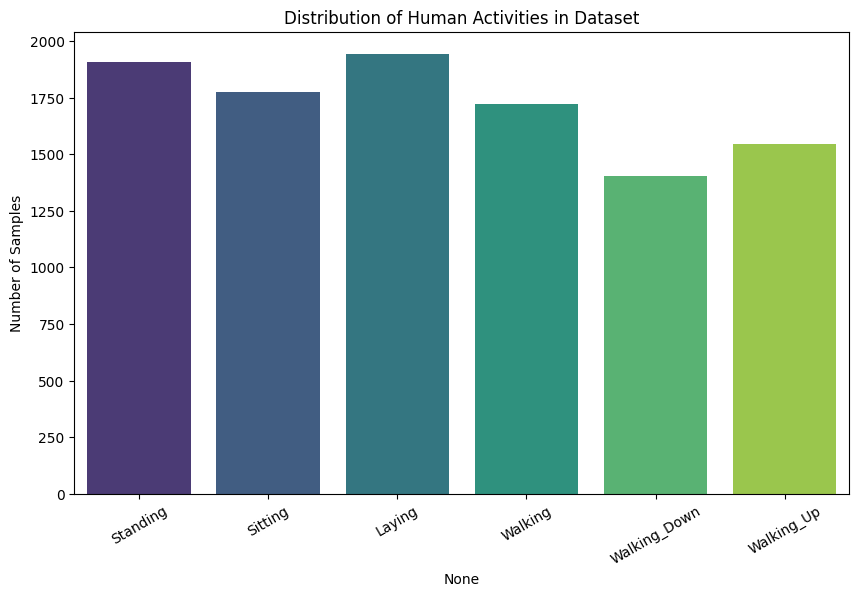

In [9]:
# I map the numeric IDs to meaningful names
activity_map = {1: 'Walking', 2: 'Walking_Up', 3: 'Walking_Down',
                4: 'Sitting', 5: 'Standing', 6: 'Laying'}
y_readable = pd.Series(y_labels).map(activity_map)

plt.figure(figsize=(10, 6))
sns.countplot(x=y_readable, palette="viridis", hue=y_readable, legend=False)
plt.title("Distribution of Human Activities in Dataset")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.show()

## **Visualizing Sensor Overlap (EDA)**
I will pick two specific features—one from the Accelerometer and one from the Gyroscope—to see how they interact. This helps me understand if the sensors are providing complementary information.

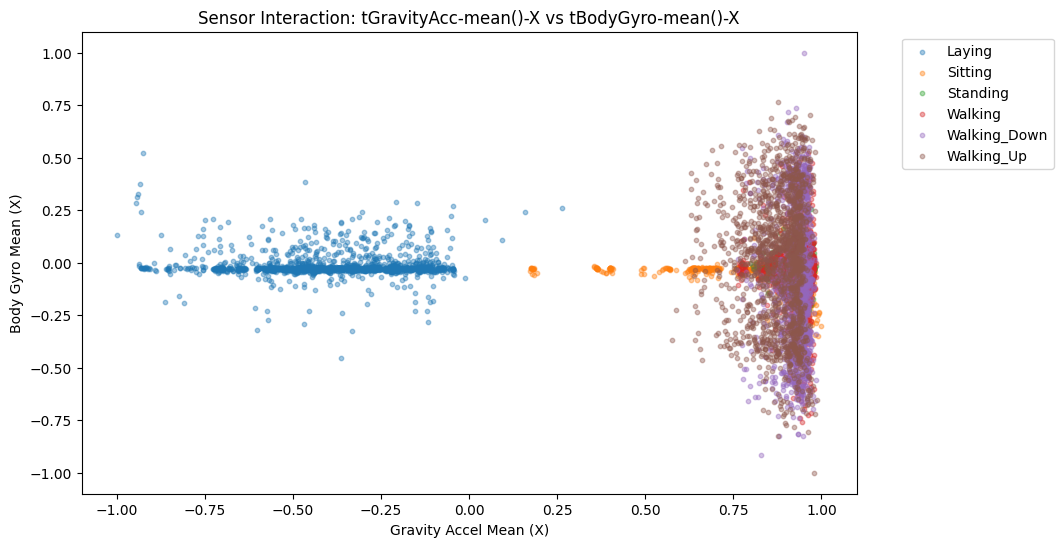

In [10]:
# I am selecting a gravity acceleration feature and a body gyro feature
feat_1 = 'tGravityAcc-mean()-X'
feat_2 = 'tBodyGyro-mean()-X'

plt.figure(figsize=(10, 6))
for activity in np.unique(y_readable):
    subset = X[y_readable == activity]
    plt.scatter(subset[feat_1], subset[feat_2], label=activity, alpha=0.4, s=10)

plt.title(f"Sensor Interaction: {feat_1} vs {feat_2}")
plt.xlabel("Gravity Accel Mean (X)")
plt.ylabel("Body Gyro Mean (X)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# **Exploratory Data Analysis: PCA Clustering**
Since I have over 500 features, I am using PCA to reduce them to 2 dimensions. This visualization is crucial because it shows me if the activities are "linearly separable"—for instance, "Laying" usually forms a very distinct cluster compared to "Walking."

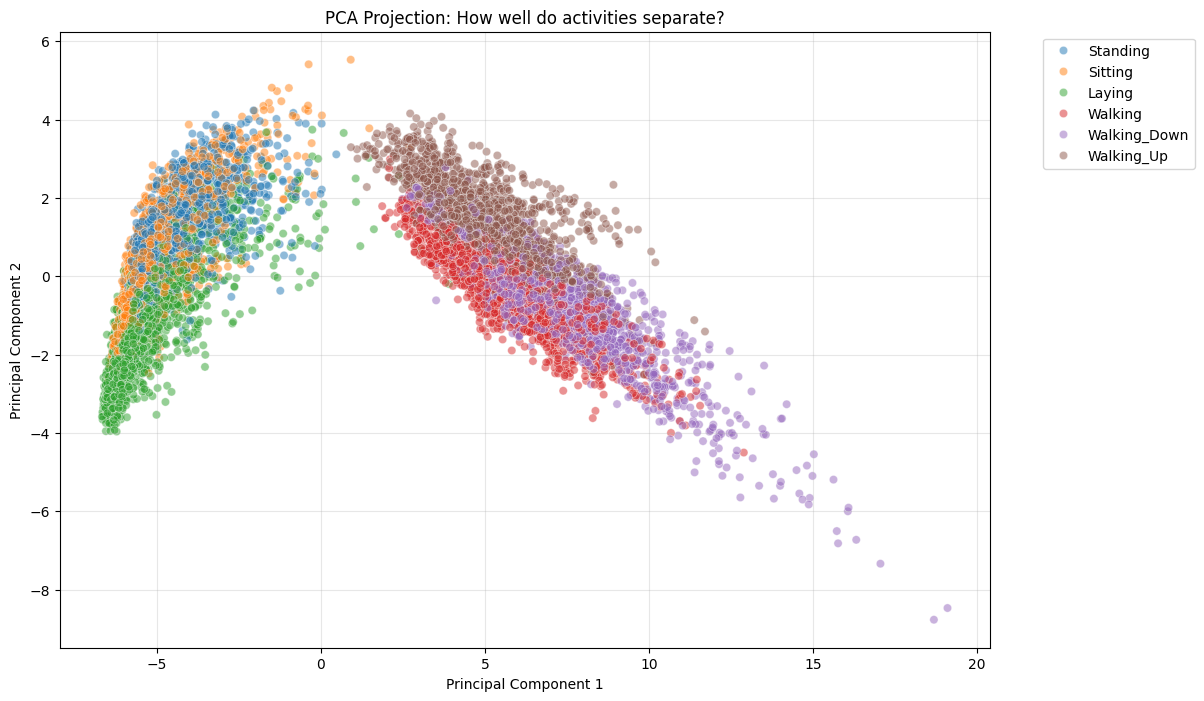

In [11]:
# I am applying PCA to see the data in 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_readable, alpha=0.5, palette="tab10")
plt.title("PCA Projection: How well do activities separate?")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## **Signal Comparison: Static vs. Dynamic Activities**
I want to see how the total acceleration magnitude differs between static activities (Laying, Sitting, Standing) and dynamic ones (Walking). This helps me understand why the model might find it easy to distinguish movement from rest.

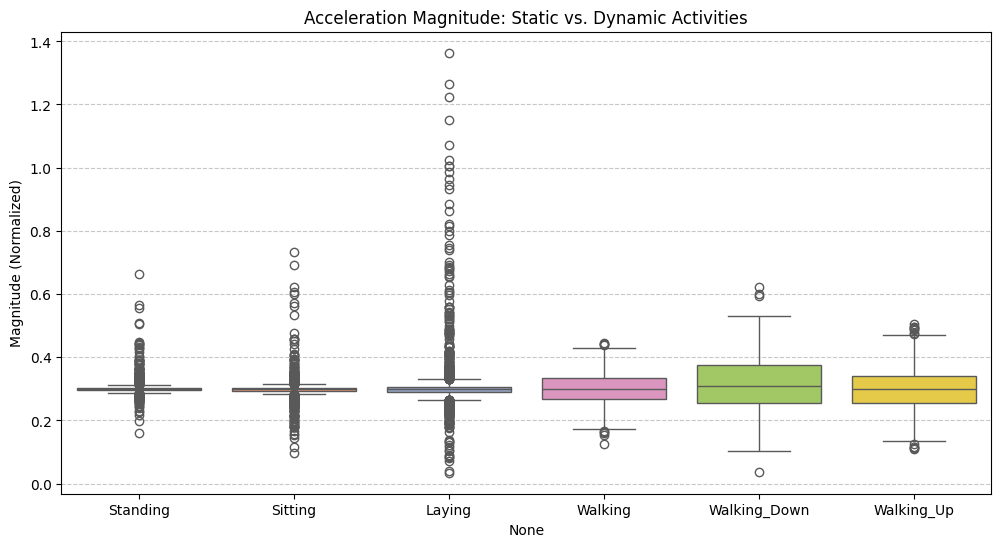

In [12]:
# I am calculating the magnitude of the 3D acceleration mean
# tBodyAcc-mean()-X is feature index 0, Y is 1, Z is 2
X['acc_magnitude'] = np.sqrt(X.iloc[:, 0]**2 + X.iloc[:, 1]**2 + X.iloc[:, 2]**2)

plt.figure(figsize=(12, 6))
sns.boxplot(x=y_readable, y=X['acc_magnitude'], palette="Set2", hue=y_readable, legend=False)
plt.title("Acceleration Magnitude: Static vs. Dynamic Activities")
plt.ylabel("Magnitude (Normalized)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Numerical Class Distribution**
I am using the value_counts() method on the mapped activity labels to show exactly how many samples exist for each category. This helps identify if the dataset is balanced.



In [13]:
# I am creating a frequency table for the activities
distribution = y_readable.value_counts().reset_index()
distribution.columns = ['Activity', 'Count']
distribution['Percentage (%)'] = (distribution['Count'] / distribution['Count'].sum() * 100).round(2)

print("--- Class Distribution ---")
print(distribution.to_string(index=False))

# I am also printing the total to verify the sample count
print(f"\nTotal Samples: {len(y_readable)}")

--- Class Distribution ---
    Activity  Count  Percentage (%)
      Laying   1944           18.88
    Standing   1906           18.51
     Sitting   1777           17.25
     Walking   1722           16.72
  Walking_Up   1544           14.99
Walking_Down   1406           13.65

Total Samples: 10299


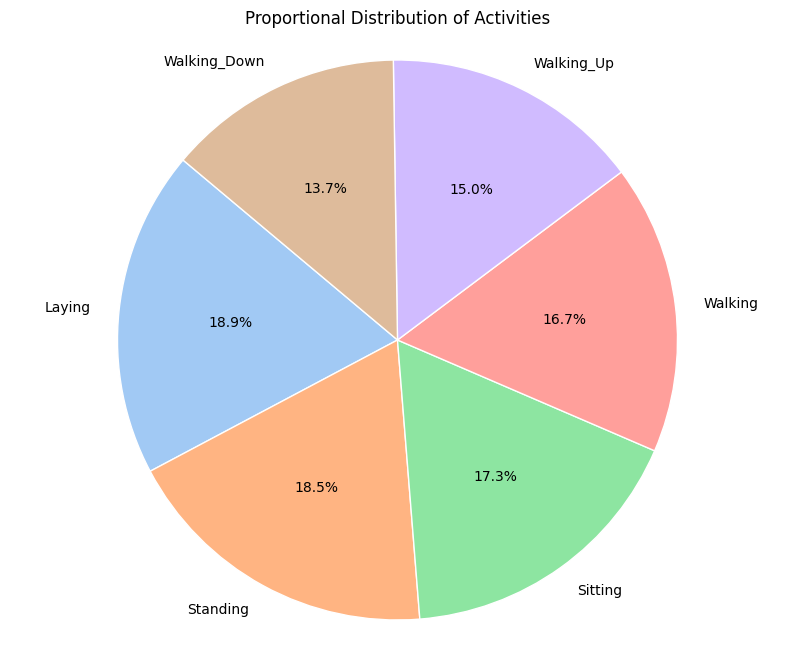

In [14]:
# I am calculating the counts for each activity to use in the pie chart
activity_counts = y_readable.value_counts()

# I am defining a color palette for the slices
colors = sns.color_palette('pastel')[0:6]

# I am creating the pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    activity_counts,
    labels=activity_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Proportional Distribution of Activities")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# **Preprocessing: Cleaning and Scaling**
I am renaming the columns to ensure they are unique and then scaling the data. Since SVMs calculate the distance between data points, having all features on the same scale (mean 0, variance 1) is essential for accuracy.

In [15]:
# I am ensuring all 561 column names are unique to avoid index errors
cols = pd.Series(X.columns)
for i in range(len(cols)):
    count = cols.iloc[:i].tolist().count(cols.iloc[i])
    if count > 0:
        cols.iloc[i] = f"{cols.iloc[i]}_{count}"
X.columns = cols

# I am splitting the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# I am standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing finished. Training on {X_train_scaled.shape[0]} samples.")

Preprocessing finished. Training on 8239 samples.


# **Training and Benchmarking Models**
In this cell, I initialize the three models and a dictionary to store their performance data. I am measuring the time taken for .fit() (training) and .predict() (testing) to provide the efficiency metrics you requested.

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time

# I am defining the models to be trained
models = {
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# I am creating a container for the results
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    # I measure Training Time
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()

    # I measure Testing Time (Inference)
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    end_test = time.time()

    # I calculate Accuracy and other weighted metrics
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train Time (s)": end_train - start_train,
        "Test Time (s)": end_test - start_test,
        "Predictions": y_pred,
        "Probabilities": y_prob
    }

# I am displaying the numerical results as a table for comparison
performance_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Train Time (s)', 'Test Time (s)']]
display(performance_df)

NameError: name 'KNeighborsClassifier' is not defined

# **Plotting Confusion Matrices**
I am plotting the confusion matrices for all three models side-by-side. This allows me to see if certain models are better at distinguishing between specific "activity pairs," like the notorious difficulty in separating "Sitting" from "Standing."

In [ ]:
# I am creating a multi-plot figure to compare the three models
fig, axes = plt.subplots(1, 3, figsize=(25, 9))

for i, (name, data) in enumerate(results.items()):
    # I am generating the confusion matrix for the current model
    cm = confusion_matrix(y_test, data["Predictions"])

    # I am using 'annot_kws' to bold the values inside the cells
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=axes[i],
                annot_kws={'size': 13, 'weight': 'bold'},
                xticklabels=list(activity_map.values()),
                yticklabels=list(activity_map.values()))

    # I am setting the titles and axis labels with bold formatting
    axes[i].set_title(f"Confusion Matrix: {name}", fontweight='bold', fontsize=14, pad=15)

    # Bolding the X and Y axis labels
    axes[i].set_xlabel("Predicted Activity", fontweight='bold', fontsize=13)
    axes[i].set_ylabel("Actual Activity", fontweight='bold', fontsize=13)

    # Bolding the tick labels (Activity Names on the axes)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), fontweight='bold', rotation=45)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.show()

# **Plotting Multi-Class ROC Curves**
Since this is a multi-class problem (6 activities), I am binarizing the labels to calculate the Receiver Operating Characteristic (ROC) curve for each model. This plot visualizes the trade-off between the True Positive Rate and False Positive Rate.

In [ ]:
# I am binarizing the output for ROC calculation
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

for name, data in results.items():
    # Calculate Macro-average ROC
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], data["Probabilities"][:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    plt.plot(all_fpr, mean_tpr, label=f'{name} (area = {auc(all_fpr, mean_tpr):.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

# I am defining the labels for the legend
class_names = list(activity_map.values())

# I am creating a figure with one subplot per model
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for idx, (name, data) in enumerate(results.items()):
    ax = axes[idx]

    # I am retrieving the probabilities for the current model
    y_prob = data["Probabilities"]

    # I will calculate and plot the ROC curve for each of the 6 classes
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        # I am plotting the curve for each specific activity
        ax.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

    # I am adding the diagonal reference line
    ax.plot([0, 1], [0, 1], 'k--', lw=1)

    # I am bolding the labels and titles as requested earlier
    ax.set_title(f"Class-Wise ROC: {name}", fontweight='bold', fontsize=14)
    ax.set_xlabel("False Positive Rate", fontweight='bold', fontsize=12)
    ax.set_ylabel("True Positive Rate", fontweight='bold', fontsize=12)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Hyperparameter Tuning**
I will now perform Hyperparameter Tuning using GridSearchCV. This process allows me to systematically search through a range of parameters for each model to find the optimal combination that yields the highest accuracy.

## **Defining the Parameter Grids**
I am setting up a dictionary of parameters for each model. For the SVM, I am testing different kernels and regularization values; for Random Forest, I am adjusting the depth and number of trees; and for KNN, I am testing different neighbor counts.

In [ ]:
from sklearn.model_selection import GridSearchCV

# I am defining the parameter search space for each model
param_grids = {
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

# I am initializing the models again for the Grid Search
base_models = {
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

print("Parameter grids defined for all models.")

## **Executing Grid Search and Benchmarking**
In this cell, I am running the GridSearchCV with 3-fold cross-validation. I will extract the best estimator for each model, then re-evaluate them on the testing set to capture the new performance metrics and the time taken.

In [ ]:
tuned_results = {}

for name, model in base_models.items():
    print(f"Starting Hyperparameter Tuning for {name}...")

    # I am initializing Grid Search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    # I measure Total Tuning and Training Time
    start_tune = time.time()
    grid_search.fit(X_train_scaled, y_train)
    end_tune = time.time()

    best_model = grid_search.best_estimator_

    # I measure Testing Time (Inference)
    start_test = time.time()
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)
    end_test = time.time()

    # I calculate the metrics
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    tuned_results[name] = {
        "Best Params": grid_search.best_params_,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Tuning Time (s)": end_tune - start_tune,
        "Inference Time (s)": end_test - start_test,
        "Predictions": y_pred,
        "Probabilities": y_prob
    }
    print(f"Best Parameters for {name}: {grid_search.best_params_}")

# I am displaying the performance of the tuned models
tuned_performance_df = pd.DataFrame(tuned_results).T[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Tuning Time (s)', 'Inference Time (s)']]
display(tuned_performance_df)

## **Visualizing Performance with Billed Confusion Matrices**
I am plotting the confusion matrices for these optimized models. Just as before, I am bolding the cell values and axis labels to ensure the final report is clear and professional.

In [ ]:
# I am creating the figure for comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (name, data) in enumerate(tuned_results.items()):
    cm = confusion_matrix(y_test, data["Predictions"])

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Greens',
                ax=axes[i],
                annot_kws={'size': 12, 'weight': 'bold'},
                xticklabels=list(activity_map.values()),
                yticklabels=list(activity_map.values()))

    axes[i].set_title(f"Tuned Confusion Matrix: {name}", fontweight='bold', fontsize=14)
    axes[i].set_xlabel("Predicted Activity", fontweight='bold', fontsize=12)
    axes[i].set_ylabel("Actual Activity", fontweight='bold', fontsize=12)

    axes[i].set_xticklabels(axes[i].get_xticklabels(), fontweight='bold', rotation=45)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.show()

## **Class-Wise ROC for Tuned Models**
I am generating the final ROC curves for the optimized models. This allows me to see if the hyperparameter tuning improved the model's ability to separate the most difficult classes.

In [ ]:
plt.figure(figsize=(12, 8))

for name, data in tuned_results.items():
    # I calculate the macro-average ROC for the tuned models
    fpr = dict()
    tpr = dict()

    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], data["Probabilities"][:, j])

    all_fpr = np.unique(np.concatenate([fpr[j] for j in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for j in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
    mean_tpr /= n_classes

    plt.plot(all_fpr, mean_tpr, label=f'Tuned {name} (Macro-AUC = {auc(all_fpr, mean_tpr):.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve Comparison: Optimized Models', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **K-Fold Cross-Validation**

## **Applying K-Fold Cross-Validation**
I am using cross_val_score to run each tuned model through 10 different folds. I will then calculate the Mean Accuracy and the Standard Deviation for each. A low standard deviation indicates that the model is robust and generalizes well to new data.

In [ ]:
from sklearn.model_selection import cross_val_score

# I am ensuring X_final is defined by removing the temporary magnitude column if it exists
if 'acc_magnitude' in X.columns:
    X_final = X.drop(columns=['acc_magnitude'])
else:
    X_final = X

# I am creating a dictionary to store the K-Fold results
kfold_results = {}

print("Starting 10-Fold Cross-Validation on tuned models...")

for name, data in tuned_results.items():
    # I am re-scaling the full dataset for a robust cross-validation
    X_scaled_full = scaler.fit_transform(X_final)

    # I am recreating the models using the 'Best Params' identified during tuning
    if name == "SVM":
        model_to_check = SVC(**data["Best Params"], probability=True, random_state=42)
    elif name == "Random Forest":
        model_to_check = RandomForestClassifier(**data["Best Params"], random_state=42)
    elif name == "KNN":
        model_to_check = KNeighborsClassifier(**data["Best Params"])

    # I am running 10-Fold CV to measure consistency
    cv_scores = cross_val_score(model_to_check, X_scaled_full, y_labels, cv=10, n_jobs=-1)

    kfold_results[name] = {
        "Scores": cv_scores,
        "Mean Accuracy": cv_scores.mean(),
        "Std Deviation": cv_scores.std()
    }

    print(f"Completed K-Fold for {name}.")

# I am displaying the stability results
kfold_df = pd.DataFrame(kfold_results).T[['Mean Accuracy', 'Std Deviation']]
display(kfold_df)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Defining the project schedule based on your updated timeline
schedule = [
    {"Task": "Research & Literature Review", "Start": "2026-01-19", "End": "2026-02-01", "Status": "Complete"},
    {"Task": "Data Acquisition & EDA", "Start": "2026-02-02", "End": "2026-02-15", "Status": "Complete"},
    {"Task": "Baseline Model Development", "Start": "2026-02-16", "End": "2026-03-01", "Status": "Complete"},
    {"Task": "Grid Search & PCA Optimization", "Start": "2026-03-02", "End": "2026-03-15", "Status": "In Progress"},
    {"Task": "Sequential Modeling (LSTM/GRU)", "Start": "2026-03-16", "End": "2026-03-29", "Status": "Planned"},
    {"Task": "XAI & SHAP Interpretability", "Start": "2026-03-30", "End": "2026-04-12", "Status": "Planned"},
    {"Task": "Final Reporting & Submission", "Start": "2026-04-13", "End": "2026-04-27", "Status": "Planned"}
]

df = pd.DataFrame(schedule)
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])
df['Duration'] = (df['End'] - df['Start']).dt.days

# Define colors based on status
color_map = {"Complete": "#2ecc71", "In Progress": "#f1c40f", "Planned": "#3498db"}
df['Color'] = df['Status'].map(color_map)

# Initialize the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Create bars
for i, row in df.iterrows():
    ax.barh(row['Task'], row['Duration'], left=row['Start'], color=row['Color'], edgecolor='black', alpha=0.8)
    # Add status text inside/beside the bar
    ax.text(row['Start'] + pd.Timedelta(days=row['Duration']/2), i, row['Status'],
            va='center', ha='center', color='black', fontweight='bold')

# Formatting the timeline
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)

# Labels and Styling
ax.set_xlabel('Project Timeline (2026)')
ax.set_title('Gantt Chart: HAR Framework Development Schedule', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()  # Most recent tasks at the bottom
ax.grid(axis='x', linestyle='--', alpha=0.5)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, lw=4, label=s) for s, c in color_map.items()]
ax.legend(handles=legend_elements, loc='upper right', title="Task Status")

plt.tight_layout()
plt.show()